In [1]:
import numpy as np
import json, copy, os, glob
import scipy.integrate as spi
import astropy.units as u
from astropy.coordinates import SkyCoord
import astropy.cosmology.units as cu
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1 import AxesGrid
from datetime import date

from enterprise_extensions import model_utils
#sns.color_palette("YlOrBr", as_cmap=True)

from astropy import units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import patheffects
from matplotlib import text

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py
import healpy as hp
from healpy.newvisufunc import projview, newprojplot

#from la_forge import core as co
#from la_forge.utils import bayes_fac
#import seaborn as sns
'''
import la_forge.core as co
import la_forge.diagnostics as dg

from la_forge.rednoise import gorilla_bf
from pint.models import get_model
'''

'\nimport la_forge.core as co\nimport la_forge.diagnostics as dg\n\nfrom la_forge.rednoise import gorilla_bf\nfrom pint.models import get_model\n'

In [2]:
#conda install conda-forge::la_forge

In [3]:
def compute_levels(H, X, Y, levels=(0.68, 0.95)):
    # Compute the density levels.
    Hflat = H.flatten()
    inds = np.argsort(Hflat)[::-1]
    Hflat = Hflat[inds]
    sm = np.cumsum(Hflat)
    sm /= sm[-1]
    V = np.empty(len(levels))
    for i, v0 in enumerate(levels):
        try:
            V[i] = Hflat[sm <= v0][-1]
        except IndexError:
            V[i] = Hflat[0]
    V.sort()
    m = np.diff(V) == 0
    if np.any(m) and not quiet:
        logging.warning("Too few points to create valid contours")
    while np.any(m):
        V[np.where(m)[0][0]] *= 1.0 - 1e-4
        m = np.diff(V) == 0
    V.sort()

    # Compute the bin centers.
    X1, Y1 = 0.5 * (X[1:] + X[:-1]), 0.5 * (Y[1:] + Y[:-1])

    # Extend the array for the sake of the contours at the plot edges.
    H2 = H.min() + np.zeros((H.shape[0] + 4, H.shape[1] + 4))
    H2[2:-2, 2:-2] = H
    H2[2:-2, 1] = H[:, 0]
    H2[2:-2, -2] = H[:, -1]
    H2[1, 2:-2] = H[0]
    H2[-2, 2:-2] = H[-1]
    H2[1, 1] = H[0, 0]
    H2[1, -2] = H[0, -1]
    H2[-2, 1] = H[-1, 0]
    H2[-2, -2] = H[-1, -1]
    X2 = np.concatenate(
        [
            X1[0] + np.array([-2, -1]) * np.diff(X1[:2]),
            X1,
            X1[-1] + np.array([1, 2]) * np.diff(X1[-2:]),
        ]
    )
    Y2 = np.concatenate(
        [
            Y1[0] + np.array([-2, -1]) * np.diff(Y1[:2]),
            Y1,
            Y1[-1] + np.array([1, 2]) * np.diff(Y1[-2:]),
        ]
    )
    return H2, X2, Y2, V

In [4]:
def get_bayes_fac(c, amp_param='log10_mc'):

    BF,BF_err = model_utils.bayes_fac(samples = samples_cold[0][::,4], logAmax=-11)
    print('log10A BF = ', BF, " +- ", BF_err)

    return BF
    '''
    idx = c.params.index(amp_param)
    pmin = float(c.priors[idx][c.priors[idx].index('pmin')+5:
                               c.priors[idx].index(', pmax')])
    pmax = float(c.priors[idx][c.priors[idx].index('pmax')+5:
                               c.priors[idx].index(')')])
    BF, _ = bayes_fac(c.chain[c.burn:, idx], logAmin=pmin, logAmax=pmax)
    if np.isnan(BF):
        BF = gorilla_bf(c.chain[c.burn:, idx], max=pmax, min=pmin, nbins=20)
    return BF
    '''

In [5]:
def skymap_ra(ra):
    return -ra + np.pi

In [6]:
def plot_BF_skymap(
    c, ra_deg, dec_deg,
    BFcond=True, BFs=None, c_NGC3115=None,
    pcolor=True, bins=40, BF_cmap='bone_r', contour=True,
    levels=(0.1,0.25,0.5,0.95), cmap='copper',
    label_psrs=[], save=None, psrsize=55, xaxis_color='k',
    logBF=False, include_BFcbar=True, BF_vmin=0, BF_vmax='auto',
    psr_color='blue'
):
    """
    Plots a skymap with CW significance in terms of Bayes factors.
    """

    freq = -8.43  # fixed log10_fGW

    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection='mollweide')

    # ---------------------------------------------------------
    # Bayes factor map from all-sky search
    # ---------------------------------------------------------
    BF_variedCW = get_bayes_fac(c)

    phi_post = skymap_ra(samples_cold[0][:, 2])
    gwtheta_post = -np.arccos(samples_cold[0][:, 0]) + np.pi/2

    #post_hist, phi, theta = np.histogram2d(
     #   phi_post, gwtheta_post, bins=bins, density=True
    #)
    
    post_hist, phi_edges, dec_edges = np.histogram2d(
    phi_post, gwtheta_post, bins=bins, density=True
    )

    area25 = credible_region_area(phi_edges, dec_edges, post_hist, 0.25)
    area68 = credible_region_area(phi_edges, dec_edges, post_hist, 0.68)
    area95 = credible_region_area(phi_edges, dec_edges, post_hist, 0.95)

    print("25% credible area =", area25, "deg^2")
    print("68% credible area =", area68, "deg^2")
    print("95% credible area =", area95, "deg^2")

    
    #cos_theta_grid = ((np.cos(theta)[:-1] + np.cos(theta)[1:]) / 2)[np.newaxis, :]
    cos_theta_grid = ((np.cos(dec_edges)[:-1] + np.cos(dec_edges)[1:]) / 2)[np.newaxis, :]

    skyloc_prior = cos_theta_grid / (4 * np.pi)

    BF = BF_variedCW / skyloc_prior * post_hist

    if BF_vmax == 'auto':
        BF_vmax = np.max(BF)

    # ---------------------------------------------------------
    # Pseudocolor: BF or posterior
    # ---------------------------------------------------------
    if pcolor:

        if BFcond:
            pcm = ax.pcolormesh(
                np.linspace(-np.pi, np.pi, bins),
                np.linspace(-np.pi/2, np.pi/2, bins),
                BF.T, cmap=BF_cmap, zorder=0,
                shading='gouraud', vmin=BF_vmin, vmax=BF_vmax
            )
            if include_BFcbar:
                cb = plt.colorbar(
                    pcm, ax=ax, location="right", fraction=0.036, pad=0.07
                )
                cb.set_label(
                    'Bayes Factor per Sky Location',
                    fontsize=13
                )

        else:
            pcm = ax.pcolormesh(
                np.linspace(-np.pi, np.pi, bins),
                np.linspace(-np.pi/2, np.pi/2, bins),
                post_hist.T, cmap='bone_r', zorder=0,
                shading='gouraud'
            )
            if include_BFcbar:
                cb = plt.colorbar(
                    pcm, ax=ax, location="right", fraction=0.036, pad=0.07
                )
                cb.set_label('Posterior Probability', fontsize=13)

    # ---------------------------------------------------------
    # Contours
    # ---------------------------------------------------------
    if contour:
        #H2, X2, Y2, V = compute_levels(post_hist, phi, theta, levels=levels)
        H2, X2, Y2, V = compute_levels(post_hist, phi_edges, dec_edges, levels=levels)

        plt.contour(X2, Y2, H2.T, V, cmap=cmap, vmin=0, vmax=np.max(V))

    # ---------------------------------------------------------
    # Targeted Bayes factors (fixed-sky runs)
    # ---------------------------------------------------------
    if BFs is not None:

        if logBF:
            vmax = np.log10(np.max(list(BFs.values())))
            vmin = -vmax
            cmap_fixed = 'RdGy_r'
        else:
            vmin = 0
            vmax = np.max(list(BFs.values()))
            cmap_fixed = 'inferno'

        for ra_dec in BFs:
            val = np.log10(BFs[ra_dec]) if logBF else BFs[ra_dec]

            ra_str, dec_str = ra_dec.split('_')
            coord = SkyCoord(ra_str, dec_str, frame='icrs')

            sc = ax.scatter(
                [skymap_ra(np.radians(coord.ra.value))],
                [np.radians(coord.dec.value)],
                c=val, cmap=cmap_fixed,
                vmin=vmin, vmax=vmax,
                marker='o', s=160, edgecolors='k', lw=0.5, zorder=2
            )

        cb = plt.colorbar(sc, ax=ax, location="bottom", fraction=0.046, pad=0.07)
        cb.set_label(
            'Log Bayes Factor for fixed frequency' if logBF else
            'Bayes Factor per Sky Location',
            fontsize=15
        )

    # ---------------------------------------------------------
    # PULSAR SKY LOCATIONS
    # ---------------------------------------------------------
    ra_rad = np.radians(np.array(list(ra_deg)))
    dec_rad = np.radians(np.array(list(dec_deg)))

    ax.scatter(
        np.pi - ra_rad, dec_rad,
        color=psr_color, marker='*', s=psrsize,
        label='Pulsars', zorder=3,
        edgecolor='c', lw=0.3
    )

    # ---------------------------------------------------------
    # *** CW SOURCE MARKER (replaces NGC3115) ***
    # ---------------------------------------------------------
    gw_phi = 3.3335788713091694        # RA (radians)
    gw_theta = 0.6387905062299246      # polar angle theta
    gw_dec = np.pi/2 - gw_theta        # DEC (radians)

    gw_RA_plot = skymap_ra(gw_phi)
    gw_DEC_plot = gw_dec

    print("CW source (RA, DEC) =", gw_phi, gw_dec)

    ax.scatter(
        [gw_RA_plot], [gw_DEC_plot],
        color='black', marker='D', s=200,
        edgecolors='k', lw=0.5, zorder=5,
        label='CW source'
    )

    # ---------------------------------------------------------
    # Axis formatting
    # ---------------------------------------------------------
    ax.grid(True)
    ax.set_xlabel('RA', color=xaxis_color)
    ax.set_ylabel('DEC')

    ax.legend()

    xlabels = [
        r'$22^{\rm{h}}$', r'$20^{\rm{h}}$', r'$18^{\rm{h}}$',
        r'$16^{\rm{h}}$', r'$14^{\rm{h}}$', r'$12^{\rm{h}}$',
        r'$10^{\rm{h}}$', r'$8^{\rm{h}}$', r'$6^{\rm{h}}$',
        r'$4^{\rm{h}}$', r'$2^{\rm{h}}$'
    ]
    ax.set_xticklabels(xlabels, color=xaxis_color)

    #ax.set_title(
     #   "log10_fGW = %1.1f  (log10_h SD BF = %1.2f)" %
      #  (freq, BF_variedCW),
       # fontsize=15
    #)

    fig.tight_layout()

    plt.savefig(
        "/scratch/na00078/projects/15yr_broad_targeted/post_processing/all_sky/plots/without_J1713/"
        "all_sky_%1.1f_withBF_CWsource_without_J1713.png" % freq
    )

    if save:
        savestr = 'skymap'
        if BFs is not None:
            savestr += '_logBFs' if logBF else '_BFs'
        if BFcond:
            savestr = 'BF' + savestr
        print("Saving:", savestr)
        plt.savefig(
            f'{save}/{savestr}.png', format='png', dpi=300, bbox_inches='tight'
        )


In [7]:
def credible_region_area(phi, dec, post_hist, level):
    """
    Compute the HPD credible region area for a given probability level.
    phi, dec: bin edges (radians)
    post_hist: posterior probability density histogram
    level: fraction of posterior mass (0.25, 0.68, 0.95)
    """

    # Convert histogram to probability mass inside each pixel
    dphi = np.diff(phi)
    ddec = np.diff(dec)
    dec_centers = 0.5 * (dec[:-1] + dec[1:])

    # solid angle for each pixel: dΩ = cos(dec) ddec dphi
    dOmega = np.outer(np.cos(dec_centers) * ddec, dphi)

    # pixel probability = density * dOmega
    pixel_prob = post_hist * dOmega

    # flatten
    flat_prob = pixel_prob.flatten()
    flat_dOmega = dOmega.flatten()

    # sort by descending probability density
    idx = np.argsort(flat_prob)[::-1]
    sorted_prob = flat_prob[idx]
    sorted_dOmega = flat_dOmega[idx]

    # cumulative probability
    cdf = np.cumsum(sorted_prob)
    cdf /= cdf[-1]

    # number of pixels needed
    Npix = np.where(cdf >= level)[0][0] + 1

    # compute area
    area_sr = np.sum(sorted_dOmega[:Npix])
    area_deg2 = area_sr * (180/np.pi)**2

    return area_deg2


In [8]:
import json
import numpy as np

# ----------------------------------------------------
# Load JSON containing:
#   data[name][0] = [x,y,z]
#   data[name][1] = [RA(rad), DEC(rad)]
# ----------------------------------------------------
with open("pulsar_positions.json") as f:
    data = json.load(f)

psrnames = []
psr_RAs  = []
psr_DECs = []

for name, vals in data.items():
    psrnames.append(name)

    RA  = vals[1][0]   # radians
    DEC = vals[1][1]   # radians

    psr_RAs.append(RA)
    psr_DECs.append(DEC)

# ----------------------------------------------------
# Convert to degrees (if needed)
# ----------------------------------------------------
ra_deg  = np.degrees(psr_RAs)
dec_deg = np.degrees(psr_DECs)

# For your plotting function:
#   Use np.radians if you want them in radians.
# ----------------------------------------------------
ra_rad  = np.radians(ra_deg)
dec_rad = np.radians(dec_deg)

print("RA (deg): ", ra_deg[:5])
print("DEC (deg):", dec_deg[:5])


RA (deg):  [ 7.61428458  8.59097587 34.52648873 69.31630209 93.43323196]
DEC (deg): [  4.86103042  -5.57686723  42.53816173 -47.25255794  -2.01311817]


In [9]:
#CHANGE THIS FILE BASED ON YOUR RUN OUTPUT

core = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_detect_allsky_outfile.h5"     #co.Core(corepath='/scratch/na00078/QuickCW_targeted_runs/results/NGC3115_allsky_core.h5')

with h5py.File(core, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

(100000000, 8)
(1, 100000000)


In [10]:
#THESE FILES SHOULD NOT BE CHANGED
ra = np.genfromtxt('gwphi.txt')
print(np.min(ra))
print(np.max(ra))
dec =np.genfromtxt('cos_gwtheta.txt')
print(np.min(dec))
print(np.max(dec))

0.00010049682293618283
6.282922552406807
-0.9999592611944104
0.9999375785177382


log10A BF =  33.205336878086264  +-  0.08146159939464316
25% credible area = 720.086133513375 deg^2
68% credible area = 2869.7637730330935 deg^2
95% credible area = 7981.157719096997 deg^2
CW source (RA, DEC) = 3.3335788713091694 0.9320058205649719


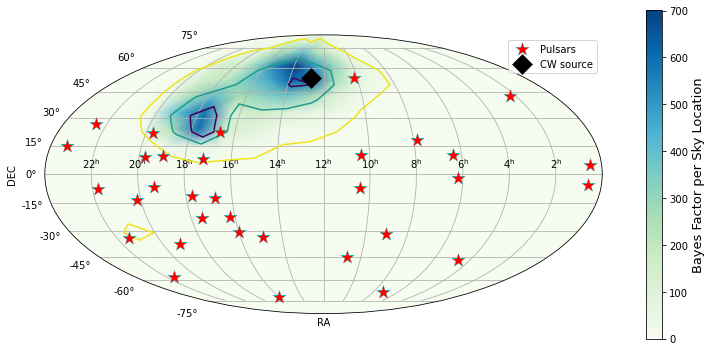

In [11]:
#Plot skymap

levels = (0.25, 0.68, 0.95)

plot_BF_skymap(
    samples_cold, ra_deg, dec_deg,
    BFcond=True, BFs=None, c_NGC3115=None,
    bins=20, xaxis_color='black', psr_color='red',
    pcolor=True, contour=True, psrsize=200,
    label_psrs=['J1713+0747'], levels=levels, cmap='viridis_r',
    save=False,
    BF_vmin=0,
    BF_vmax=None,
    BF_cmap='GnBu'# if the function supports log normalization
)